# Identificação de Perfis de Risco em Apostadores Online por Meio de Aprendizado de Máquina

**Nome:** Livia Negrucci Cantowitz RA 10389419

**Histórico de alterações:**
| Data | Autor | Descrição |
|---|---|---|
|24/09 e 25/09 | Livia Negrucci Cantowitz | Tudo |


**Datasets:** bets.csv é o dataset original, obtido do [Sports Betting Profiling Dataset](https://www.kaggle.com/datasets/emiliencoicaud/sports-betting-profiling-dataset) no Kaggle.

apostadores_perfil_risco.csv é a base tratada, gerada a partir dele.



1- Carregamento e inspeção do dataset

2- Análise exploratória


3- Definição da regra de classificação de risco


## 1. Importação das bibliotecas e carregamento dos dados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Se estiver rodando no Colab, faça upload do bets.csv antes (ícone de pasta à esquerda > upload)
df = pd.read_csv("apostadores_perfil_risco.csv")
print(df.shape)
df.head()

(5000, 13)


,user_id,n_bets,total_stake,avg_stake,max_stake,win_rate,total_gain,total_ggr,avg_odds,pct_multiple,max_losing_streak,risk_score,risk_profile
0,1,22,776.30,35.286364,65.2,0.318182,688.01,88.29,5.799091,0.272727,3,-2.013971,baixo
1,2,14,70.75,5.053571,8.4,0.142857,11.06,59.69,4.447143,0.500000,6,-0.612989,medio
2,3,21,1785.25,85.011905,122.3,0.476190,2817.67,-1032.42,4.459048,0.476190,4,-0.174404,medio
3,4,10,139.15,13.915000,24.2,0.100000,22.07,117.08,5.866000,0.300000,6,-3.261769,baixo
4,5,25,329.45,13.178000,23.6,0.440000,849.05,-519.60,5.064400,0.320000,5,-0.500553,medio


## 2. Análise exploratória inicial

In [7]:
print("Total de apostadores:", len(df))
print("Total de apostadores únicos:", df["user_id"].nunique())
print()
print(df.dtypes)
print()
print("Valores nulos por coluna:")
print(df.isnull().sum())

Total de apostadores: 5000
Total de apostadores únicos: 5000

user_id                int64
n_bets                 int64
total_stake          float64
avg_stake            float64
max_stake            float64
win_rate             float64
total_gain           float64
total_ggr            float64
avg_odds             float64
pct_multiple         float64
max_losing_streak      int64
risk_score           float64
risk_profile          object
dtype: object

Valores nulos por coluna:
user_id              0
n_bets               0
total_stake          0
avg_stake            0
max_stake            0
win_rate             0
total_gain           0
total_ggr            0
avg_odds             0
pct_multiple         0
max_losing_streak    0
risk_score           0
risk_profile         0
dtype: int64


In [8]:
df.describe()

,user_id,n_bets,total_stake,avg_stake,max_stake,win_rate,total_gain,total_ggr,avg_odds,pct_multiple,max_losing_streak,risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2500.500000,20.000000,2652.633030,132.003894,195.599160,0.364485,2385.715830,266.917200,4.699779,0.349560,5.253400,3.694822e-16
std,1443.520003,4.464032,3055.181508,145.160162,204.402541,0.110856,3378.667384,1882.248145,1.037827,0.108460,2.271083,2.543876e+00
min,1.000000,6.000000,34.700000,3.393750,7.400000,0.000000,0.000000,-26652.490000,1.784667,0.000000,1.000000,-1.047197e+01
25%,1250.750000,17.000000,648.937500,35.078492,66.200000,0.285714,422.290000,-121.960000,3.972985,0.277778,4.000000,-1.694038e+00
50%,2500.500000,20.000000,1688.725000,81.885119,122.800000,0.363636,1293.085000,124.255000,4.622290,0.350000,5.000000,-2.056135e-01
75%,3750.250000,23.000000,3631.512500,174.689423,248.800000,0.437500,3089.387500,743.070000,5.320119,0.421053,6.000000,1.406969e+00
max,5000.000000,39.000000,23025.400000,815.000000,1000.000000,0.812500,48309.590000,11970.340000,9.922500,0.727273,19.000000,1.336032e+01


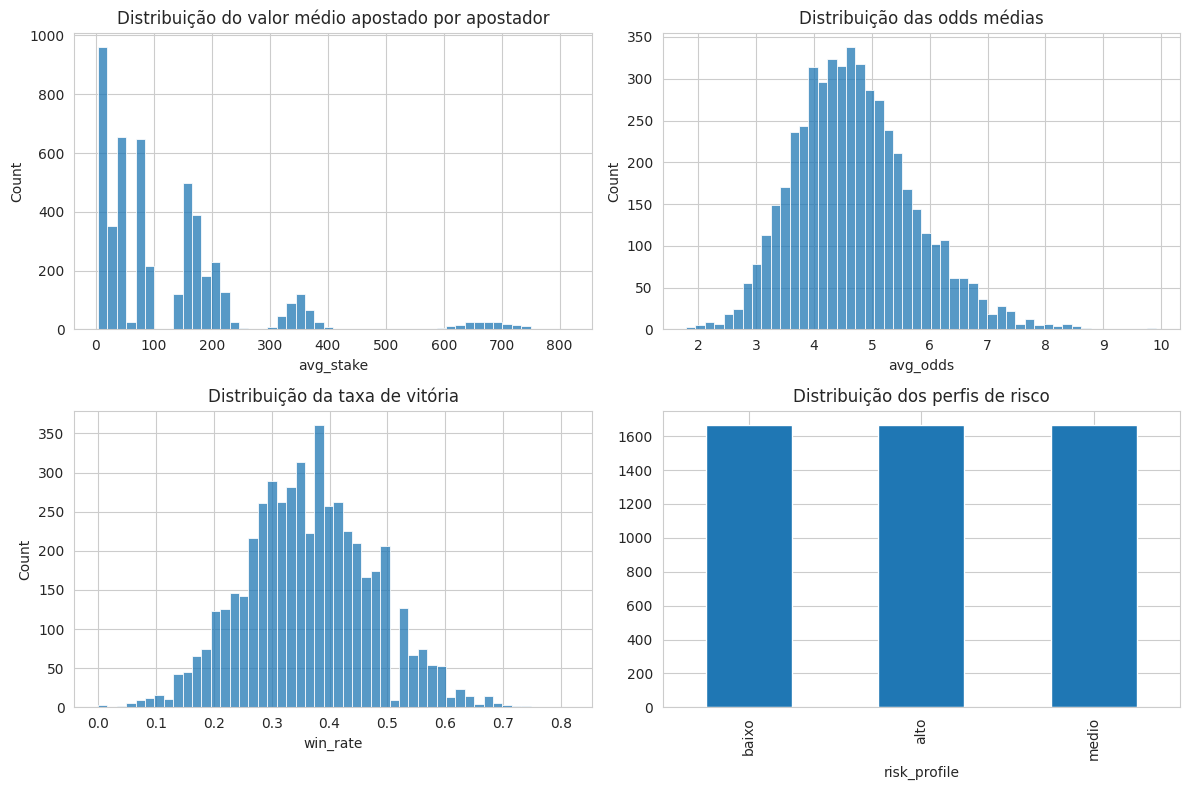

In [10]:
ffig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["avg_stake"], bins=50, ax=axes[0,0])
axes[0,0].set_title("Distribuição do valor médio apostado por apostador")

sns.histplot(df["avg_odds"], bins=50, ax=axes[0,1])
axes[0,1].set_title("Distribuição das odds médias")

sns.histplot(df["win_rate"], bins=50, ax=axes[1,0])
axes[1,0].set_title("Distribuição da taxa de vitória")

df["risk_profile"].value_counts().plot(kind="bar", ax=axes[1,1])
axes[1,1].set_title("Distribuição dos perfis de risco")

plt.tight_layout()
plt.show()

## 3. Definição da regra de classificação de risco


In [14]:
df["risk_profile"].value_counts()

,count
risk_profile,
baixo,1667
alto,1667
medio,1666


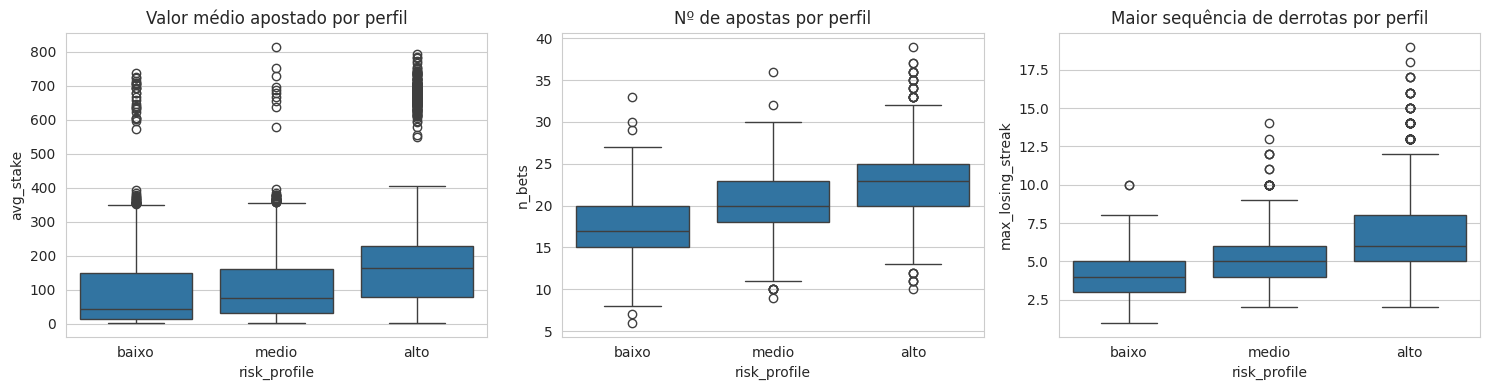

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, x="risk_profile", y="avg_stake", ax=axes[0])
axes[0].set_title("Valor médio apostado por perfil")

sns.boxplot(data=df, x="risk_profile", y="n_bets", ax=axes[1])
axes[1].set_title("Nº de apostas por perfil")

sns.boxplot(data=df, x="risk_profile", y="max_losing_streak", ax=axes[2])
axes[2].set_title("Maior sequência de derrotas por perfil")

plt.tight_layout()
plt.show()